In [1]:
!pip install ucimlrepo

In [2]:
#Import the function used to download the dataset
from ucimlrepo import fetch_ucirepo

In [3]:
#Download the UCI Heart Disease dataset
heart_disease = fetch_ucirepo(id=45)

In [4]:
# Features
X = heart_disease.data.features

# Target (labels)
y = heart_disease.data.targets

In [5]:
# Create binary target
# 0 = no heart disease
# 1 = heart disease present
#Selects the first column of y which is greater than 0
y_binary = (y.iloc[:, 0] > 0).astype(int)

print(y_binary.value_counts())

num
0    164
1    139
Name: count, dtype: int64


In [6]:
from sklearn.model_selection import train_test_split
#randon state =42, keep the random split the same every time run the code
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_binary,
    test_size=0.2,
    random_state=42,
    stratify=y_binary
)

In [7]:
# Separate the features
# Continuous variables
numeric_features = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]
# Categorical variables
categorical_features = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "ca",
    "thal"
]

In [8]:
# Import tye ColumnTransformer class to apply different preprocessing methods to different columns
from sklearn.compose import ColumnTransformer
#A pipeline connects several processing steps so they run in the correct order automatically (Missing-value handling->Standardization->LR)
from sklearn.pipeline import Pipeline
#Fill in missing values
from sklearn.impute import SimpleImputer
#Satndardizes numberical + categorical features
from sklearn.preprocessing import StandardScaler, OneHotEncoder
#Import the model
from sklearn.linear_model import LogisticRegression

In [9]:
# Processing for continuous features
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")), #missing value is replaced with the median of that feature
    ("scaler", StandardScaler()) # Syandardizes each numerical feature
])

# Processing for categorical features
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")), #missing value is replaced with the most common category in training set
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

In [10]:
# Apply different preprocessing to different columns
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

In [11]:
# Complete model pipeline
lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),#Standardizes the feature values
    ("model", LogisticRegression(max_iter=1000))#allows the model up to 1,000 training iterations to find suitable coefficients
])
# Train on the training set
lr_pipeline.fit(X_train, y_train.values.ravel())
# make predictions
lr_pred = lr_pipeline.predict(X_test)
#probability
lr_prob = lr_pipeline.predict_proba(X_test)[:, 1]

In [12]:
#shape=num of column
print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(242, 13)
(61, 13)
(242,)
(61,)


In [13]:
print(lr_pred)

[0 1 0 0 0 0 0 0 1 0 1 0 0 1 1 1 1 1 1 1 1 0 1 0 1 0 0 1 0 1 0 1 1 1 0 1 0
 0 0 1 1 1 1 1 0 0 1 0 1 0 0 1 0 0 0 1 1 1 0 0 1]


In [14]:
# Import the accuracy calculation function
from sklearn.metrics import accuracy_score

In [15]:
#Calculate the accuracy
accuracy = accuracy_score(y_test, lr_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8852459016393442


The model correctly predicted 88.5% of the
patients in the testing set.

In [16]:
# Import the martix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, lr_pred)

print(cm)

# Import the classification
from sklearn.metrics import classification_report
print(classification_report(y_test,lr_pred))

[[28  5]
 [ 2 26]]
              precision    recall  f1-score   support

           0       0.93      0.85      0.89        33
           1       0.84      0.93      0.88        28

    accuracy                           0.89        61
   macro avg       0.89      0.89      0.89        61
weighted avg       0.89      0.89      0.89        61



### Observation

Logistic Regression achieved the highest accuracy of approximately 88.5%. It correctly identified 28 of the 33 patients without heart disease and 26 of the 28 patients with heart disease.

The model had a disease recall of 0.93, meaning that it detected approximately 93% of patients who truly had heart disease. It produced only two false negatives and five false positives, giving it the strongest overall performance among the tested models.

## Binary Classification

The original target contained five classes from 0 to 4. In this section, the labels were converted into a binary target.

- 0 = No heart disease
- 1 = Heart disease present

Classes 1–4 were combined into one disease-positive group. This makes the task simpler and allows the model to focus on detecting whether heart disease is present rather than predicting disease severity.

## Binary Class Distribution

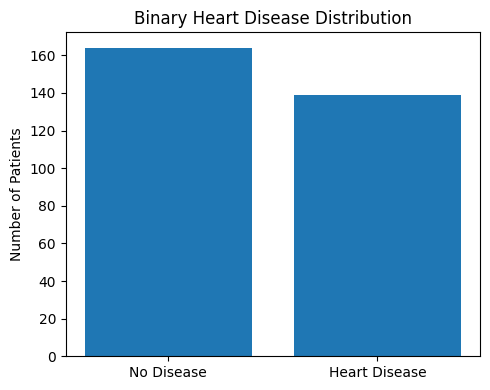

num
0    164
1    139
Name: count, dtype: int64


In [17]:
import matplotlib.pyplot as plt

counts = y_binary.value_counts().sort_index()

plt.figure(figsize=(5,4))

plt.bar(
    ["No Disease","Heart Disease"],
    counts.values
)

plt.ylabel("Number of Patients")
plt.title("Binary Heart Disease Distribution")

plt.tight_layout()

plt.savefig(
    "binary_class_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(counts)

### Observation

The binary dataset contains both patients with and without heart disease. Although the classes are not perfectly balanced, both groups contain a sufficient number of samples for model training and evaluation.

Using a binary target simplifies the prediction task compared with the original five-class classification problem.

## DummyClassifier Model

In [18]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [19]:
#DummyClassifier verfication code
dummy_model = DummyClassifier( strategy="most_frequent" )
dummy_model.fit( X_train, y_train.values.ravel() )
dummy_pred = dummy_model.predict(X_test)
dummy_accuracy = accuracy_score( y_test.values.ravel(), dummy_pred )
print("Dummy accuracy:", dummy_accuracy)
print("Confusion matrix:")
print(confusion_matrix(y_test, dummy_pred))
print( classification_report( y_test, dummy_pred, zero_division=0 ) )

Dummy accuracy: 0.5409836065573771
Confusion matrix:
[[33  0]
 [28  0]]
              precision    recall  f1-score   support

           0       0.54      1.00      0.70        33
           1       0.00      0.00      0.00        28

    accuracy                           0.54        61
   macro avg       0.27      0.50      0.35        61
weighted avg       0.29      0.54      0.38        61



### Observation

The DummyClassifier achieved an accuracy of 54.1% by predicting every patient as Class 0, meaning no heart disease. It correctly classified all 33 patients without heart disease but failed to identify any of the 28 patients with heart disease.

This result shows that accuracy alone can be misleading because the model achieved more than 50% accuracy without detecting a single disease-positive patient.

## Decision Tree

In [20]:
from sklearn.tree import DecisionTreeClassifier

dt_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        DecisionTreeClassifier(
            max_depth=4, # limits the tree to four levels, reducing overfitting
            random_state=42 # Makes the result reproducible
        )
    )
])

dt_pipeline.fit(X_train, y_train.values.ravel())

dt_pred = dt_pipeline.predict(X_test)
dt_prob = dt_pipeline.predict_proba(X_test)[:,1]
dt_accuracy = accuracy_score( y_test.values.ravel(), dt_pred )

print("DecisionTree accuracy:", dt_accuracy)
print("Confusion matrix:")
print(confusion_matrix(y_test, dt_pred))
print( classification_report( y_test, dt_pred, zero_division=0 ) )

DecisionTree accuracy: 0.7868852459016393
Confusion matrix:
[[25  8]
 [ 5 23]]
              precision    recall  f1-score   support

           0       0.83      0.76      0.79        33
           1       0.74      0.82      0.78        28

    accuracy                           0.79        61
   macro avg       0.79      0.79      0.79        61
weighted avg       0.79      0.79      0.79        61



### Observation

The Decision Tree achieved an accuracy of 78.7%. It correctly identified 25 of the 33 patients without heart disease and 23 of the 28 patients with heart disease.

The recall for heart disease was 0.82, meaning that the model detected approximately 82% of the disease-positive patients. However, it produced more false positives and false negatives than Logistic Regression and Random Forest.

##Random Forest Model

In [21]:
#Import the random forest model
from sklearn.ensemble import RandomForestClassifier

# create the model, built 100 decision trees
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        RandomForestClassifier(
            n_estimators=100,
            random_state=42
        )
    )
])

In [22]:
# Train the model
rf_pipeline.fit(
    X_train,
    y_train.values.ravel()
)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'trestbps', 'chol',
                                                   'thalach', 'oldpeak']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['sex', 'cp', 'fbs',
                                                   'restecg', 'exang', 'slope',
                                                   'ca', 'thal'])])),
                ('model', RandomForestClassifier(random_state=42))])

In [23]:
#Predict
rf_pred = rf_pipeline.predict(X_test)
rf_prob = rf_pipeline.predict_proba(X_test)[:,1]

In [24]:
# Evaluate
from sklearn.metrics import accuracy_score

rf_accuracy = accuracy_score(y_test.values.ravel(), rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

from sklearn.metrics import confusion_matrix

rf_cm = confusion_matrix(y_test.values.ravel(), rf_pred)

print("\nConfusion Matrix:")
print(rf_cm)

from sklearn.metrics import classification_report
print("\nClassification Report:")
print(
    classification_report(
        y_test.values.ravel(),
        rf_pred,
        zero_division=0
    )
)

Random Forest Accuracy: 0.8688524590163934

Confusion Matrix:
[[27  6]
 [ 2 26]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.82      0.87        33
           1       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61



### Observation

The Random Forest achieved an accuracy of 86.9%. It correctly identified 27 of the 33 patients without heart disease and 26 of the 28 patients with heart disease.

Its recall for heart disease was 0.93, meaning that it detected approximately 93% of the disease-positive patients. It missed only two patients with heart disease, although it incorrectly classified six healthy patients as having heart disease.

## Compare the four models

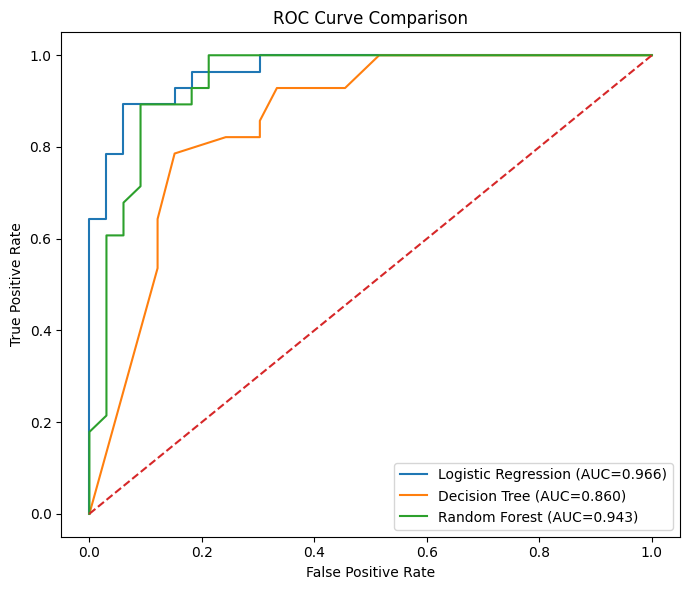

In [25]:
# ROC Curve
# Can the model distinguish healthy patients from patients with heart disease?
# Calculates the points on the ROC curve and the area under the curve
from sklearn.metrics import roc_curve, auc
#create the figure
plt.figure(figsize=(7,6))

# Stores the predicted probabilities
for name, prob in [

    ("Logistic Regression", lr_prob),

    ("Decision Tree", dt_prob),

    ("Random Forest", rf_prob)

]:
# calculate the ROC points
# FPR = FP/(FP+TN)
# TPR= Recall = TP/(TP+FN)
    fpr, tpr, _ = roc_curve(
        y_test,
        prob
    )

    roc_auc = auc(
        fpr,
        tpr
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC={roc_auc:.3f})"
    )

# Random guessing line (closer -> not learning useful patterns)
plt.plot(
    [0,1],
    [0,1],
    "--"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")
plt.legend()
plt.tight_layout()
plt.savefig(
    "ROC Curve Comparison.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

### Observation

The ROC curves show that all three machine learning models performed much better than random guessing because their curves are well above the diagonal reference line.

Logistic Regression achieved the highest AUC of **0.966**, indicating the strongest ability to distinguish between patients with and without heart disease. Random Forest also performed well with an AUC of **0.943**, while Decision Tree achieved the lowest AUC of **0.860** among the three models.

Overall, Logistic Regression demonstrated the best discrimination ability, followed closely by Random Forest. The ROC results are consistent with the evaluation metrics reported earlier, where Logistic Regression achieved the highest overall classification performance.

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Calculate metrics for each model
comparison_df = pd.DataFrame({
    "Model": [
        "DummyClassifier",
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy": [
        accuracy_score(y_test, dummy_pred),
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ],

    "Precision": [
        precision_score(y_test, dummy_pred, zero_division=0),
        precision_score(y_test, lr_pred, zero_division=0),
        precision_score(y_test, dt_pred, zero_division=0),
        precision_score(y_test, rf_pred, zero_division=0)
    ],

    "Recall": [
        recall_score(y_test, dummy_pred, zero_division=0),
        recall_score(y_test, lr_pred, zero_division=0),
        recall_score(y_test, dt_pred, zero_division=0),
        recall_score(y_test, rf_pred, zero_division=0)
    ],

    "F1-score": [
        f1_score(y_test, dummy_pred, zero_division=0),
        f1_score(y_test, lr_pred, zero_division=0),
        f1_score(y_test, dt_pred, zero_division=0),
        f1_score(y_test, rf_pred, zero_division=0)
    ],

    "ROC-AUC": [
        0.5,
        roc_auc_score(y_test, lr_prob),
        roc_auc_score(y_test, dt_prob),
        roc_auc_score(y_test, rf_prob)
    ]
})

comparison_df

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,DummyClassifier,0.540984,0.000000,0.000000,0.000000,0.500000
1,Logistic Regression,0.885246,0.838710,0.928571,0.881356,0.966450
2,Decision Tree,0.786885,0.741935,0.821429,0.779661,0.859848
3,Random Forest,0.868852,0.812500,0.928571,0.866667,0.942641


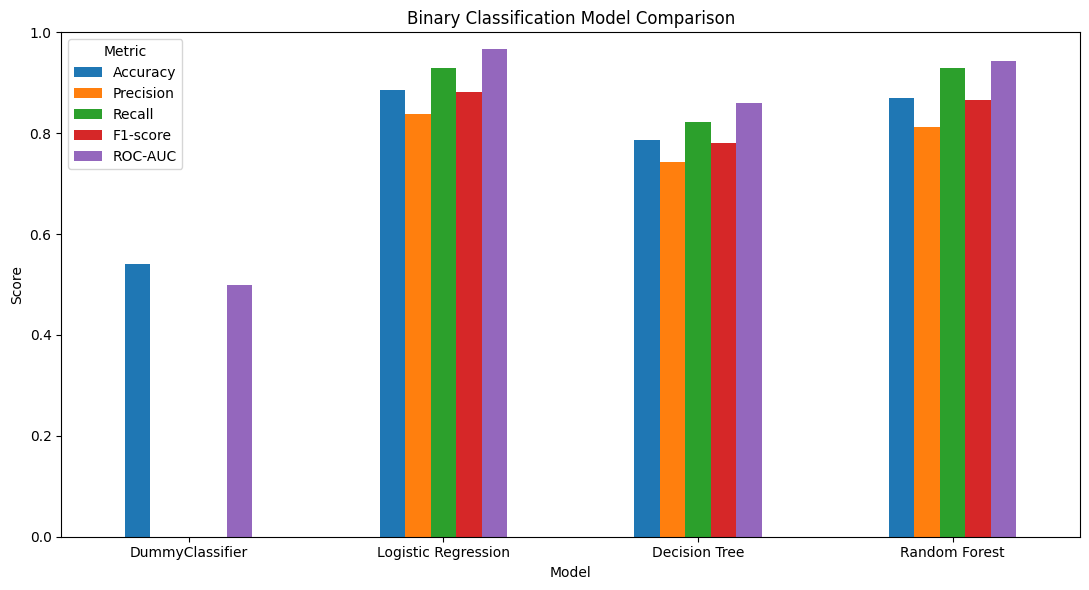

In [27]:
# Graph
comparison_plot = comparison_df.set_index("Model")

comparison_plot.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("Binary Classification Model Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.tight_layout()

plt.savefig(
    "binary_model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Stratified K-Fold
K-Fold splits the test set many times and keeps approximately the same class ratio in every fold

In [28]:
# Creates the folds
from sklearn.model_selection import StratifiedKFold
# Runs the entire training process automatically
from sklearn.model_selection import cross_val_score
# Split the dataset into 5 groups
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True, # randomly shuffle patients nefore making folds
    random_state=42 #Keeps the folds identical every time you run the notebook
)
# repeats the step 5 times (Split -> train -> predict -> accuracy)
scores = cross_val_score(

    lr_pipeline,

    X,

    y_binary,

    cv=cv,

    scoring="accuracy"

)

print(scores)

print(scores.mean())

[0.93442623 0.81967213 0.83606557 0.8        0.88333333]
0.8546994535519126


### Observation

The 5-fold Stratified Cross Validation produced accuracy scores of **0.934, 0.820, 0.836, 0.800, and 0.883**, with an average accuracy of **0.855**.

Although the accuracy varied slightly between folds, all five scores remained above 0.80, indicating that the Logistic Regression model performed consistently across different subsets of the dataset. The variation is expected because each fold uses a different training and validation split.

Overall, the cross-validation results suggest that the model has good generalization ability and that its performance is not dependent on a single train-test split.